# Using `grapes.utils` interpolation helpers on bundled data tables

This notebook demonstrates the functions in `grapes/utils.py` on the `.txt` simulation tables in `grapes/data/`:

- `create_A23_interpolators` for Ayromlou+2023 tables
- `create_crocodile_interpolators` for CROCODILE tables

In [1]:
from pathlib import Path
import glob

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from importlib_resources import files

from grapes.defs import cosmo
from grapes.utils import create_A23_interpolators, create_crocodile_interpolators

plt.rcParams.update({'font.size': 12})

In [2]:
# Locate bundled data files
data_dir = Path(files('grapes')) / 'data'
txt_files = sorted(data_dir.glob('*.txt'))
print(f'Data directory: {data_dir}')
print('Available .txt tables:')
for path in txt_files:
    print(' -', path.name)

Data directory: /home/sunil/Python/grapes/grapes/data
Available .txt tables:
 - Ayromlou2023a_Fig2_SIMBA.txt
 - Ayromlou2023a_Fig2_TNG.txt
 - Ayromlou2023b_Fig2_EAGLE.txt
 - Zhao_Zhang_CROCODILE.txt
 - Zhao_Zhang_CROCODILE_gas_only.txt


## 1) Ayromlou+2023 tables with `create_A23_interpolators`

Found 3 Ayromlou files


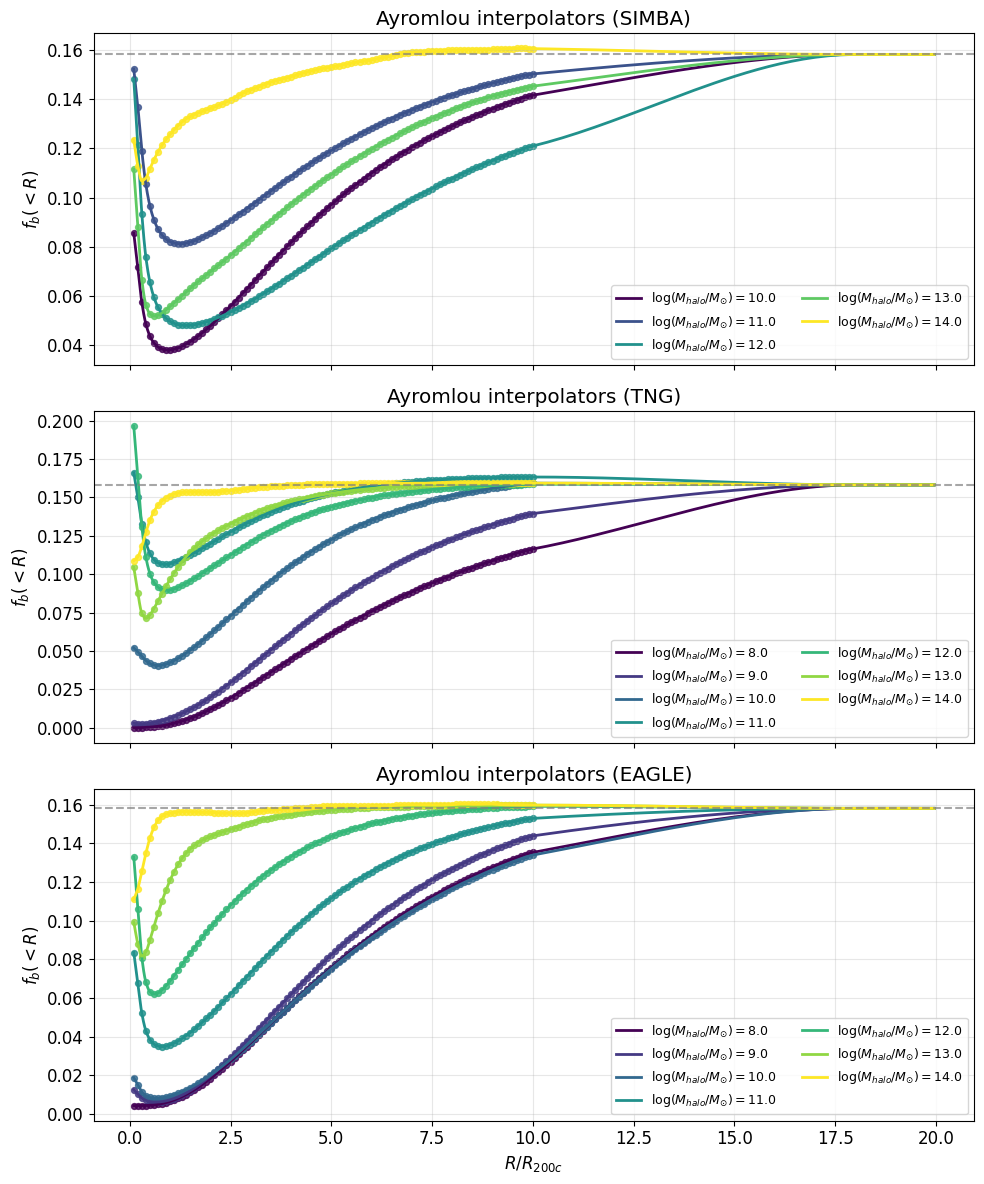

In [3]:
a23_files = sorted(glob.glob(str(data_dir / 'Ayromlou2023*_Fig2_*.txt')))
print(f'Found {len(a23_files)} Ayromlou files')

fig, axes = plt.subplots(len(a23_files), 1, figsize=(10, 4 * max(1, len(a23_files))), sharex=True, tight_layout=True)
if len(a23_files) == 1:
    axes = [axes]

for ax, file_path in zip(axes, a23_files):
    sim = Path(file_path).stem.split('_')[-1]

    tab = Table.read(
        file_path,
        format='ascii',
        names=['model_index', 'halo_mass_index', 'halo_mass_bin_value', 'x=R/R200c', 'y=f_b(<R)/f_b,cosmic']
    )

    mask = np.isfinite(tab['x=R/R200c']) & np.isfinite(tab['y=f_b(<R)/f_b,cosmic'])
    tab = tab[mask]

    interpolators = create_A23_interpolators(tab)
    x_plot = np.logspace(-1, 1.3, 300)

    colors = plt.cm.viridis(np.linspace(0, 1, max(1, len(interpolators))))
    for color, idx in zip(colors, sorted(interpolators.keys())):
        f_interp = interpolators[idx]
        sub = tab[tab['halo_mass_index'] == idx]

        x_data = np.array(sub['x=R/R200c'])
        f_data = np.array(sub['y=f_b(<R)/f_b,cosmic']) * cosmo.Ob0 / cosmo.Om0
        halo_mass = float(sub['halo_mass_bin_value'][0])

        ax.scatter(x_data, f_data, s=18, color=color, alpha=0.8)
        ax.plot(x_plot, f_interp(x_plot), color=color, lw=2,
                label=rf'$\log(M_{{halo}}/M_{{\odot}})={halo_mass:.1f}$')

    ax.axhline(cosmo.Ob0 / cosmo.Om0, color='gray', ls='--', lw=1.5, alpha=0.7)
    #ax.set_xscale('log')
    ax.set_ylabel(r'$f_b(<R)$')
    ax.set_title(f'Ayromlou interpolators ({sim})')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=9, ncol=2)

axes[-1].set_xlabel(r'$R/R_{200c}$')
plt.show()

## 2) CROCODILE tables with `create_crocodile_interpolators`

AGN label = f: 6 interpolators


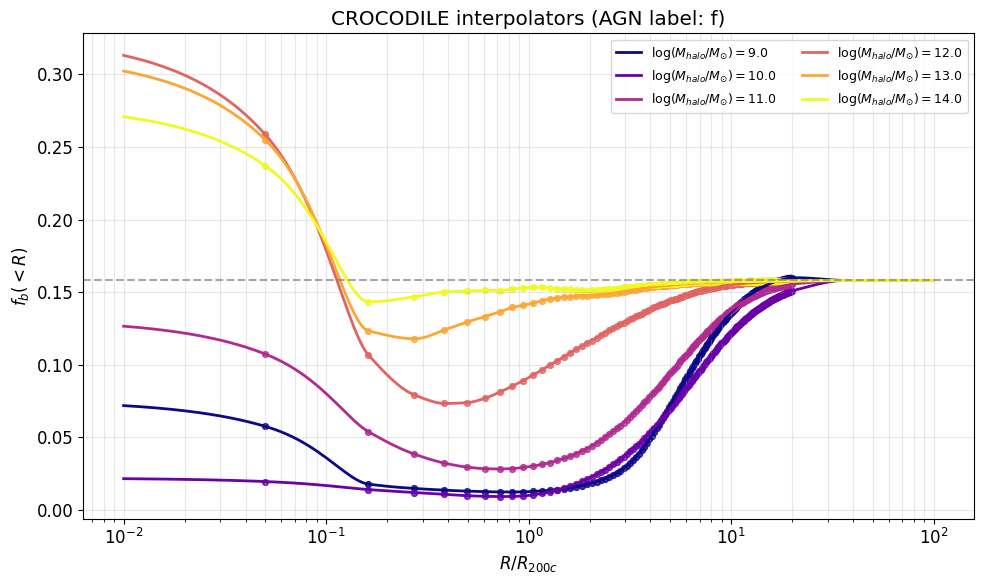

AGN label = n: 6 interpolators


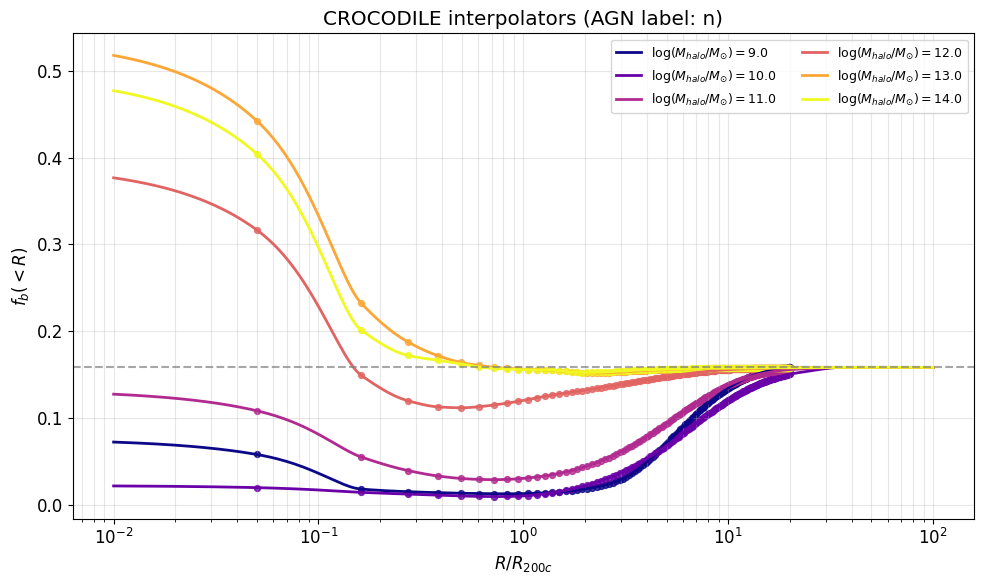

In [4]:
croc_file = data_dir / 'Zhao_Zhang_CROCODILE.txt'
croc_tab = Table.read(
    str(croc_file),
    format='ascii',
    names=['logM_lo', 'logM_up', 'label_AGN', 'R_over_R200', 'fb_med_norm', 'fb_p16_norm', 'fb_p84_norm']
)

mask = np.isfinite(croc_tab['R_over_R200']) & np.isfinite(croc_tab['fb_med_norm'])
croc_tab = croc_tab[mask]

for agn_label in ['f', 'n']:
    interpolators = create_crocodile_interpolators(croc_tab, AGN_label=agn_label)
    print(f'AGN label = {agn_label}: {len(interpolators)} interpolators')

    x_plot = np.logspace(-2, 2, 300)
    fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
    colors = plt.cm.plasma(np.linspace(0, 1, max(1, len(interpolators))))

    for color, logm in zip(colors, sorted(interpolators.keys())):
        f_interp = interpolators[logm]
        sub = croc_tab[(croc_tab['logM_lo'] == logm) & (croc_tab['label_AGN'] == agn_label)]

        x_data = np.array(sub['R_over_R200'])
        f_data = np.array(sub['fb_med_norm']) * cosmo.Ob0 / cosmo.Om0

        ax.scatter(x_data, f_data, s=18, color=color, alpha=0.8)
        ax.plot(x_plot, f_interp(x_plot), color=color, lw=2,
                label=rf'$\log(M_{{halo}}/M_{{\odot}})={logm:.1f}$')

    ax.axhline(cosmo.Ob0 / cosmo.Om0, color='gray', ls='--', lw=1.5, alpha=0.7)
    ax.set_xscale('log')
    ax.set_xlabel(r'$R/R_{200c}$')
    ax.set_ylabel(r'$f_b(<R)$')
    ax.set_title(f'CROCODILE interpolators (AGN label: {agn_label})')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=9, ncol=2)
    plt.show()

# User-specified interpolation schemes 

FloaterHormannInterpolator is available

Testing 7 interpolation schemes:
['CubicSpline', 'PchipInterpolator', 'Akima1DInterpolator', 'CubicHermiteSpline', 'BarycentricInterpolator', 'KroghInterpolator', 'FloaterHormannInterpolator']

Creating interpolators with CubicSpline...
  Created 6 interpolators

Creating interpolators with PchipInterpolator...
  Created 6 interpolators

Creating interpolators with Akima1DInterpolator...
  Created 6 interpolators

Creating interpolators with CubicHermiteSpline...
  Created 6 interpolators

Creating interpolators with BarycentricInterpolator...
  Created 6 interpolators

Creating interpolators with KroghInterpolator...
  Created 6 interpolators

Creating interpolators with FloaterHormannInterpolator...
  Created 6 interpolators


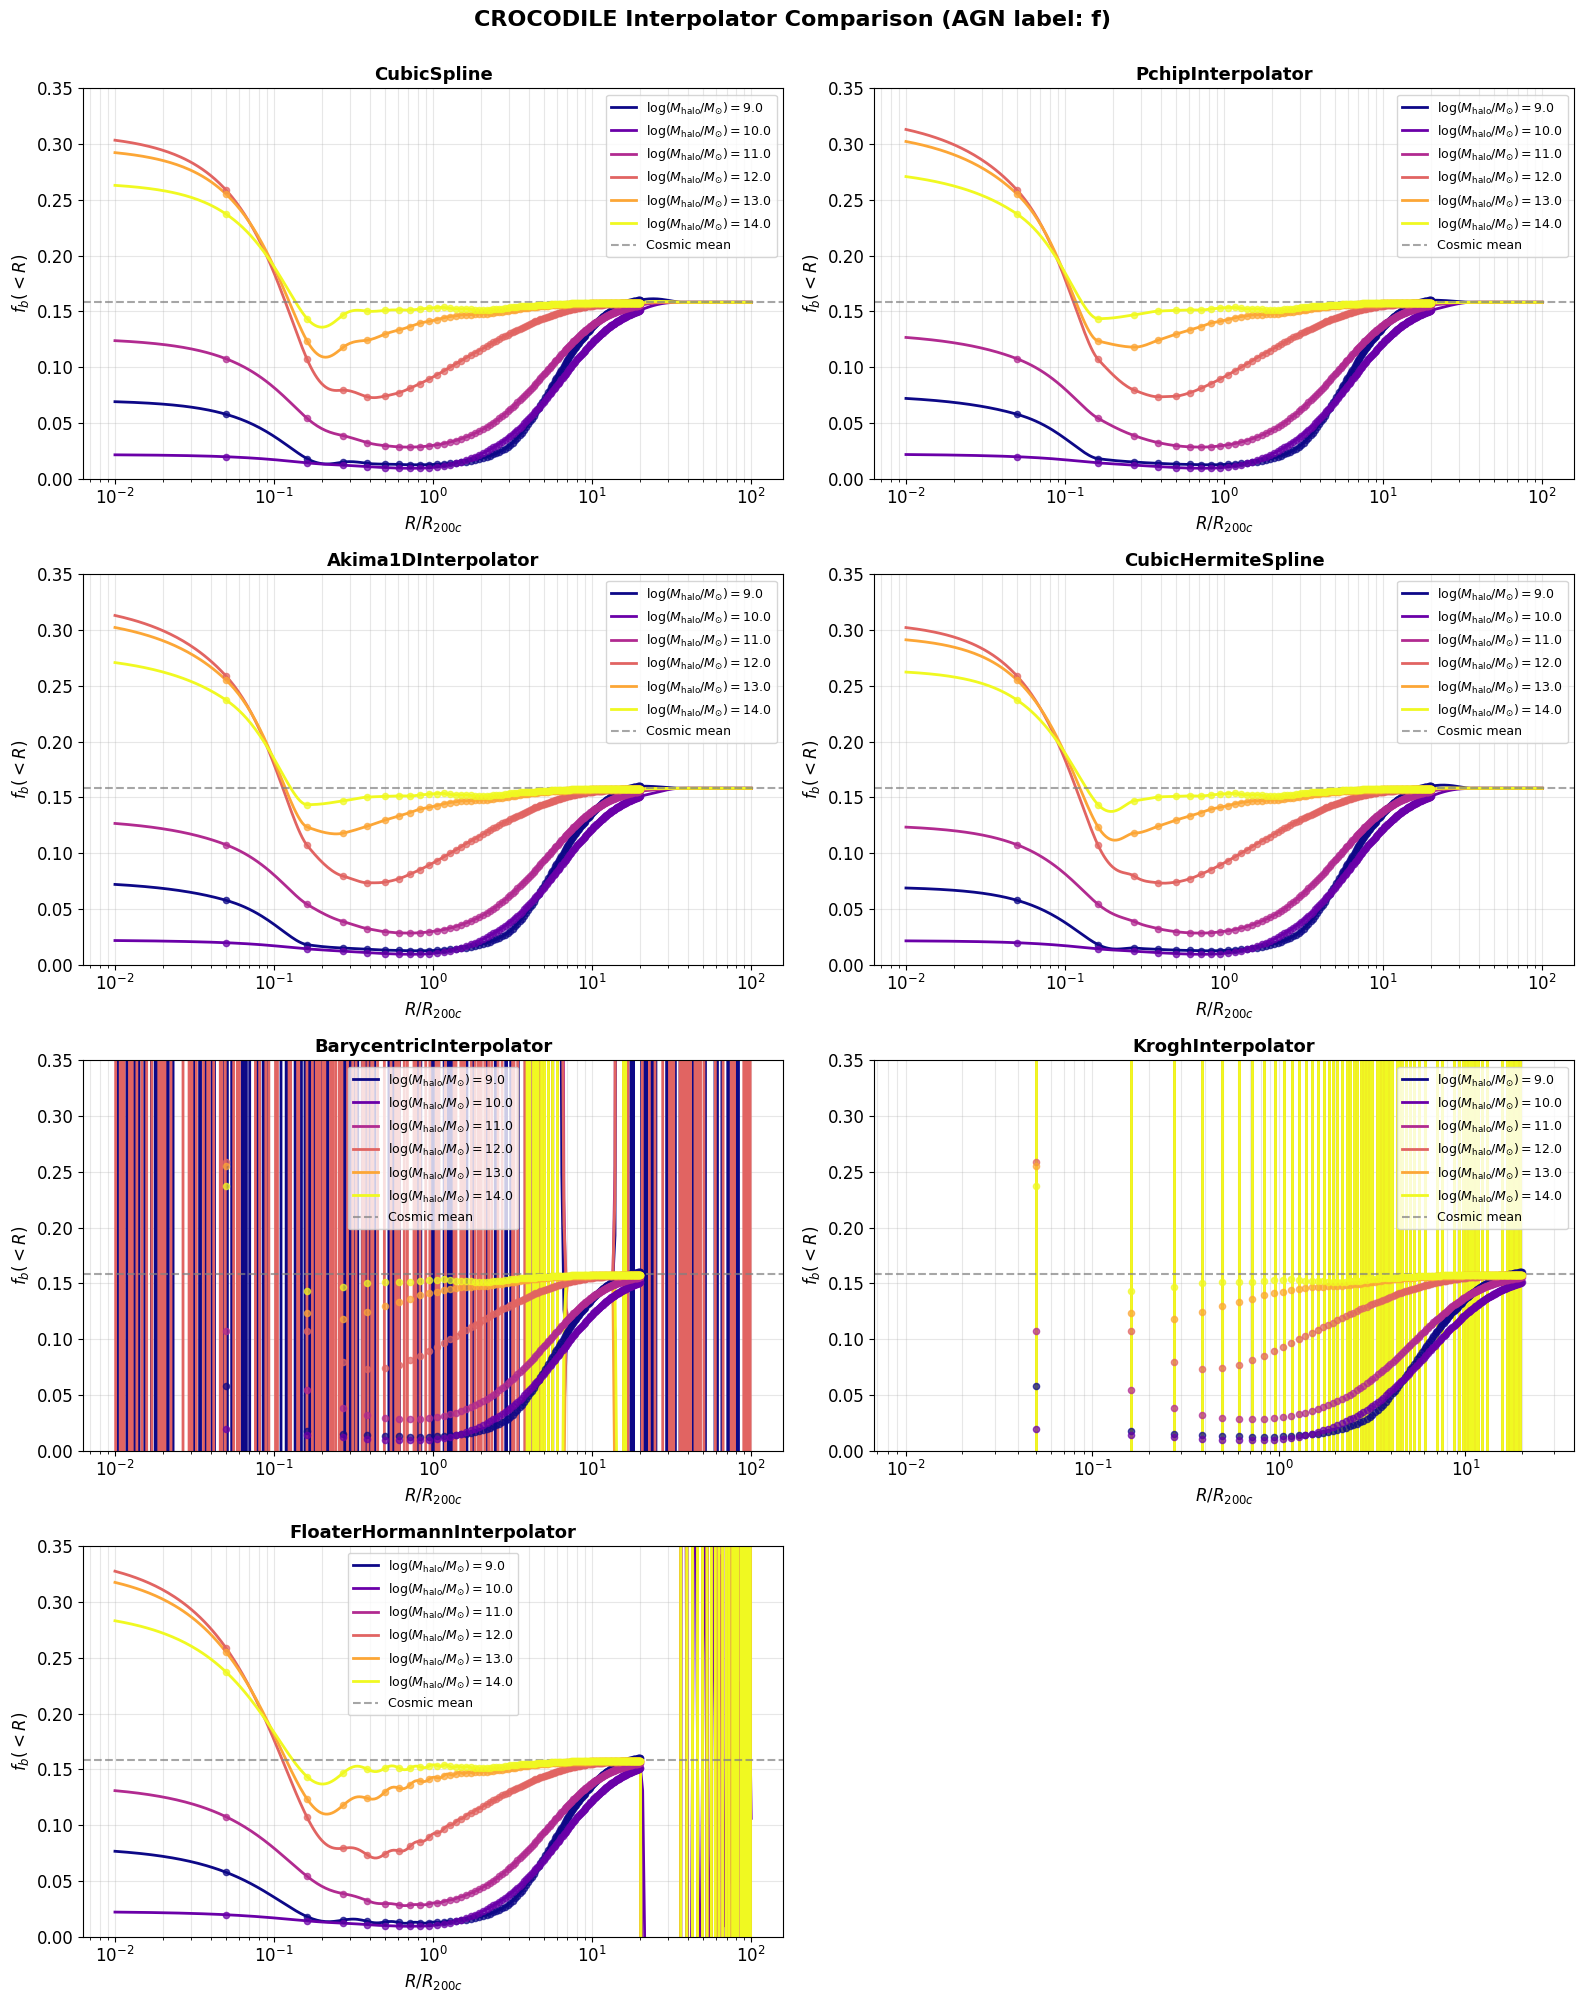


Comparison complete!


In [7]:
# Demonstrate all available interpolation schemes on CROCODILE data (AGN label 'f')

# List all supported interpolation schemes
interpolator_types = [
    'CubicSpline',
    'PchipInterpolator',
    'Akima1DInterpolator',
    'CubicHermiteSpline',
    'BarycentricInterpolator',
    'KroghInterpolator',
]

# Try to add FloaterHormannInterpolator if available
try:
    from scipy.interpolate import FloaterHormannInterpolator
    interpolator_types.append('FloaterHormannInterpolator')
    print("FloaterHormannInterpolator is available")
except ImportError:
    print("FloaterHormannInterpolator not available (requires scipy >= 1.13.0)")

print(f"\nTesting {len(interpolator_types)} interpolation schemes:")
print(interpolator_types)

# Setup for plotting
agn_label = 'f'  # fiducial AGN
x_plot = np.logspace(-2, 2, 300)
n_interp = len(interpolator_types)

# Create subplots - 2 columns
ncols = 2
nrows = (n_interp + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), tight_layout=True)
axes = axes.flatten() if n_interp > 1 else [axes]

# Loop over interpolation schemes
for idx, interp_type in enumerate(interpolator_types):
    ax = axes[idx]
    
    print(f"\nCreating interpolators with {interp_type}...")
    
    # Special handling for Akima with makima method
    if interp_type == 'Akima1DInterpolator':
        spline_args = {'method': 'makima'}
    else:
        spline_args = None
    
    try:
        # Create interpolators with specified type
        interpolators = create_crocodile_interpolators(
            croc_tab, 
            AGN_label=agn_label,
            interpolator_type=interp_type,
            spline_args=spline_args
        )
        
        print(f"  Created {len(interpolators)} interpolators")
        
        # Get colors for different mass bins
        colors = plt.cm.plasma(np.linspace(0, 1, max(1, len(interpolators))))
        
        # Plot each mass bin
        for color, logm in zip(colors, sorted(interpolators.keys())):
            f_interp = interpolators[logm]
            sub = croc_tab[(croc_tab['logM_lo'] == logm) & (croc_tab['label_AGN'] == agn_label)]
            
            x_data = np.array(sub['R_over_R200'])
            f_data = np.array(sub['fb_med_norm']) * cosmo.Ob0 / cosmo.Om0
            
            # Plot data points
            ax.scatter(x_data, f_data, s=20, color=color, alpha=0.7, zorder=3)
            
            # Plot interpolated curve
            ax.plot(x_plot, f_interp(x_plot), color=color, lw=2,
                    label=rf'$\log(M_{{\mathrm{{halo}}}}/M_{{\odot}})={logm:.1f}$')
        
        # Add cosmic mean line
        ax.axhline(cosmo.Ob0 / cosmo.Om0, color='gray', ls='--', lw=1.5, alpha=0.7, 
                   label='Cosmic mean')
        
        ax.set_xscale('log')
        ax.set_xlabel(r'$R/R_{200c}$', fontsize=12)
        ax.set_ylabel(r'$f_b(<R)$', fontsize=12)
        ax.set_title(f'{interp_type}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=9, ncol=1, loc='best')
        ax.set_ylim(0, 0.35)
        
    except Exception as e:
        print(f"  ERROR: {e}")
        ax.text(0.5, 0.5, f'Error: {interp_type}\n{str(e)}', 
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='red')
        ax.set_title(f'{interp_type} (FAILED)', fontsize=13, color='red')

# Hide unused subplots if odd number
for idx in range(n_interp, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'CROCODILE Interpolator Comparison (AGN label: {agn_label})', 
             fontsize=16, fontweight='bold', y=1.0)
plt.show()

print("\n" + "="*70)
print("Comparison complete!")